In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import joblib # Para carregar os scalers

import matplotlib.pyplot as plt

In [3]:
# -----------------------
# Funções de pertinência
# -----------------------
def gaussmf(x, mean, sigma):
    x = np.asarray(x, dtype=np.float32)
    sigma = float(sigma) if sigma != 0 else 1e-6
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2).astype(np.float32)

def trimf(x, a, b, c):
    x = np.asarray(x, dtype=np.float32)
    y = np.zeros_like(x, dtype=np.float32)
    # rising
    idx = (x >= a) & (x <= b)
    if b != a:
        y[idx] = (x[idx] - a) / (b - a)
    # falling
    idx = (x >= b) & (x <= c)
    if c != b:
        y[idx] = (c - x[idx]) / (c - b)
    return np.clip(y, 0.0, 1.0)

def trapmf(x, a, b, c, d):
    x = np.asarray(x, dtype=np.float32)
    y = np.zeros_like(x, dtype=np.float32)
    # rising
    idx = (x >= a) & (x <= b)
    if b != a:
        y[idx] = (x[idx] - a) / (b - a)
    # plateau
    idx = (x > b) & (x < c)
    y[idx] = 1.0
    # falling
    idx = (x >= c) & (x <= d)
    if d != c:
        y[idx] = (d - x[idx]) / (d - c)
    return np.clip(y, 0.0, 1.0)

# aproximação de pimf (pi-shaped) usando trapmf (parecido com fuzz.pimf)
def pimf(x, a, b, c, d):
    # assume a<=b<=c<=d
    return trapmf(x, a, b, c, d)

# zmf / smf (simples e eficiente)
def zmf(x, a, b):
    x = np.asarray(x, dtype=np.float32)
    y = np.zeros_like(x, dtype=np.float32)
    y[x <= a] = 1.0
    idx = (x > a) & (x < b)
    # suavização quadrática (aprox)
    denom = (b - a) if b != a else 1e-6
    y[idx] = 1.0 - ((x[idx] - a) / denom) ** 2
    return np.clip(y, 0.0, 1.0)

def smf(x, a, b):
    # mirror de zmf
    x = np.asarray(x, dtype=np.float32)
    y = np.zeros_like(x, dtype=np.float32)
    y[x >= b] = 1.0
    idx = (x > a) & (x < b)
    denom = (b - a) if b != a else 1e-6
    y[idx] = ((x[idx] - a) / denom) ** 2
    return np.clip(y, 0.0, 1.0)

# -----------------------
# Classe do controlador rápido
# -----------------------
class FuzzyControllerFast:
    def __init__(self, parametros_vetor, n_u_vf=181, n_u_wf=181):
        """
        parametros_vetor = [z_dp, pff_dp, mp_dp, pff_m, mp_m]
        cria e precomputa MFs e regras. Reutilize esta instância para muitas chamadas.
        """
        z_dp, pff_dp, mp_dp, pff_m, mp_m = parametros_vetor
        # guardar parâmetros
        self.params = (z_dp, pff_dp, mp_dp, pff_m, mp_m)

        # universos (mesmos que seu código original)
        self.phi_univ = np.linspace(-np.pi, np.pi, 181, dtype=np.float32)
        self.l_univ   = np.linspace(0, 5, 181, dtype=np.float32)
        self.u_vf     = np.linspace(-0.15, 0.15, n_u_vf, dtype=np.float32)
        self.u_wf     = np.linspace(-0.5, 0.5, n_u_wf, dtype=np.float32)

        # construir MFs antecedentes (funções que aceitam array x and retornam pertinência)
        # NOTE: usamos closures para fixar os parâmetros
        self.antecedent_mfs = {
            'PHI': [
                ('EN', lambda x, m=-np.pi, s=z_dp: gaussmf(x, m, s)),
                ('PNR', lambda x, m=(pff_m - np.pi), s=pff_dp: gaussmf(x, m, s)),
                ('GN', lambda x, m=(mp_m - np.pi), s=mp_dp: gaussmf(x, m, s)),
                ('MN', lambda x, m=-mp_m, s=mp_dp: gaussmf(x, m, s)),
                ('PNF', lambda x, m=-pff_m, s=pff_dp: gaussmf(x, m, s)),
                ('Z', lambda x, m=0.0, s=z_dp: gaussmf(x, m, s)),
                ('PPF', lambda x, m=pff_m, s=pff_dp: gaussmf(x, m, s)),
                ('MP', lambda x, m=mp_m, s=mp_dp: gaussmf(x, m, s)),
                ('GP', lambda x, m=(np.pi - mp_m), s=mp_dp: gaussmf(x, m, s)),
                ('PPR', lambda x, m=(np.pi - pff_m), s=pff_dp: gaussmf(x, m, s)),
                ('EP', lambda x, m=np.pi, s=z_dp: gaussmf(x, m, s)),
            ],
            'L': [
                ('MP', lambda x, a=0.01, b=0.02: zmf(x, a, b)),
                ('G',  lambda x, a=0.01, b=0.02: smf(x, a, b)),
            ]
        }

        # construir MFs consequentes (pré-computados nos universos)
        # VF terms: R, MR, P, MF, F
        self.output_vf = [
            ('R',  pimf(self.u_vf, -0.151, -0.15, -0.1, -0.05)),
            ('MR', pimf(self.u_vf, -0.1, -0.05, -0.05, 0.0)),
            ('P',  pimf(self.u_vf, -0.05, 0.0, 0.0, 0.05)),
            ('MF', pimf(self.u_vf, 0.0, 0.05, 0.05, 0.1)),
            ('F',  pimf(self.u_vf, 0.05, 0.1, 0.15, 0.151)),
        ]
        # WF terms: H, N, AH
        self.output_wf = [
            ('H',  trimf(self.u_wf, -0.5, -0.5, 0.0)),
            ('N',  trimf(self.u_wf, -0.5, 0.0, 0.5)),
            ('AH', trimf(self.u_wf, 0.0, 0.5, 0.5)),
        ]

        # mapa de nomes para índices (antecedentes)
        self.phi_terms = [name for name, _ in self.antecedent_mfs['PHI']]
        self.l_terms   = [name for name, _ in self.antecedent_mfs['L']]

        # regras: cada regra tem (antecedente_indices, (vf_cons_index, wf_cons_index))
        # usamos None para variáveis não especificadas (i.e., regra só com L)
        # ordem de variáveis: [PHI, L]
        # montado diretamente a partir do seu código:
        self.rules = [
            ([None, 0], (2, 1)),   # L['MP'] -> (VF['P'], WF['N']) ; VF index 2, WF index 1
            ([0, 1],    (0, 1)),   # PHI['EN'] & L['G'] -> (VF['R'], WF['N'])
            ([1, 1],    (1, 2)),   # PNR & G -> (MR, AH)
            ([2, 1],    (2, 2)),   # GN & G -> (P, AH)
            ([3, 1],    (2, 0)),   # MN & G -> (P, H)
            ([4, 1],    (3, 0)),   # PNF & G -> (MF, H)
            ([5, 1],    (4, 1)),   # Z & G -> (F, N)
            ([6, 1],    (3, 2)),   # PPF & G -> (MF, AH)
            ([7, 1],    (2, 2)),   # MP & G -> (P, AH)
            ([8, 1],    (2, 0)),   # GP & G -> (P, H)
            ([9, 1],    (1, 0)),   # PPR & G -> (MR, H)
            ([10,1],    (0, 1)),   # EP & G -> (R, N)
        ]

    def compute(self, phi_input, l_input):
        """
        phi_input, l_input: scalars or 1D arrays (same shape). Returns array:
        - if inputs scalar -> np.array([vf, wf])
        - if vector -> array shape (N,2) with columns [vf, wf]
        """
        # normalize inputs to arrays
        phi = np.asarray(phi_input, dtype=np.float32)
        l   = np.asarray(l_input, dtype=np.float32)

        scalar_input = (phi.shape == ())  # scalar vs vector
        if scalar_input:
            phi = phi[None]
            l   = l[None]
        # shape (N,)
        N = phi.shape[0]

        # 1) calcular pertinências por termo para cada variável
        # PHI: (K_phi, N)
        K_phi = len(self.antecedent_mfs['PHI'])
        deg_phi = np.empty((K_phi, N), dtype=np.float32)
        for k, (_name, func) in enumerate(self.antecedent_mfs['PHI']):
            deg_phi[k, :] = func(phi)

        # L: (K_l, N)
        K_l = len(self.antecedent_mfs['L'])
        deg_l = np.empty((K_l, N), dtype=np.float32)
        for k, (_name, func) in enumerate(self.antecedent_mfs['L']):
            deg_l[k, :] = func(l)

        # 2) calcular ativação de cada regra (n_rules, N)
        n_rules = len(self.rules)
        rule_acts = np.empty((n_rules, N), dtype=np.float32)
        for r, (ante_idxs, _cons) in enumerate(self.rules):
            # ante_idxs: [phi_idx_or_None, l_idx_or_None]
            parts = []
            # PHI
            if ante_idxs[0] is None:
                parts.append(np.ones(N, dtype=np.float32))
            else:
                parts.append(deg_phi[ante_idxs[0], :])
            # L
            if ante_idxs[1] is None:
                parts.append(np.ones(N, dtype=np.float32))
            else:
                parts.append(deg_l[ante_idxs[1], :])
            # AND = min
            rule_acts[r, :] = np.minimum.reduce(parts)

        # 3) agregação por termo de cada saída (VF e WF)
        n_vf_terms = len(self.output_vf)
        n_wf_terms = len(self.output_wf)
        cons_vf = np.zeros((n_vf_terms, N), dtype=np.float32)
        cons_wf = np.zeros((n_wf_terms, N), dtype=np.float32)

        for r, (_ante, (vf_idx, wf_idx)) in enumerate(self.rules):
            # máximo entre regras que apontam pro mesmo termo
            cons_vf[vf_idx, :] = np.maximum(cons_vf[vf_idx, :], rule_acts[r, :])
            cons_wf[wf_idx, :] = np.maximum(cons_wf[wf_idx, :], rule_acts[r, :])

        # 4) agregação final e defuzzificação por centróide (vetorizado)
        # Montar aggregated surfaces (N x M_vf) e (N x M_wf)
        M_vf = self.u_vf.size
        M_wf = self.u_wf.size

        aggregated_vf = np.zeros((N, M_vf), dtype=np.float32)
        for j, (_name, mf_on_u) in enumerate(self.output_vf):
            # cons_vf[j,:] (N,) * mf_on_u (M_vf,)
            aggregated_vf = np.maximum(aggregated_vf, cons_vf[j, :][:, None] * mf_on_u[None, :])

        aggregated_wf = np.zeros((N, M_wf), dtype=np.float32)
        for j, (_name, mf_on_u) in enumerate(self.output_wf):
            aggregated_wf = np.maximum(aggregated_wf, cons_wf[j, :][:, None] * mf_on_u[None, :])

        # centróide
        numer_vf = np.sum(aggregated_vf * self.u_vf[None, :], axis=1)
        denom_vf = np.sum(aggregated_vf, axis=1)
        vf_out = np.where(denom_vf > 1e-12, numer_vf / denom_vf, 0.0).astype(np.float32)

        numer_wf = np.sum(aggregated_wf * self.u_wf[None, :], axis=1)
        denom_wf = np.sum(aggregated_wf, axis=1)
        wf_out = np.where(denom_wf > 1e-12, numer_wf / denom_wf, 0.0).astype(np.float32)

        # montar retorno
        if scalar_input:
            return np.array([float(vf_out[0]), float(wf_out[0])], dtype=np.float32)
        else:
            return np.column_stack([vf_out, wf_out])  # shape (N,2)

In [4]:
def simular_malha_fechada_fast(
    ctrl_fast,                # instância de FuzzyControllerFast pré-criada
    modelo_rnn,
    angulos_ideais,
    x_scaler_rnn,
    y_scaler_rnn,
    timesteps,
    L_input_constante=1.0,
    dt_coeff=0.07
):
    """
    Versão otimizada da simulação em malha fechada.
    - ctrl_fast: FuzzyControllerFast já criado (evita recriar MFs/regras cada passo)
    - modelo_rnn: modelo Keras pronto para inferência
    - angulos_ideais: vetor dos ângulos de referência
    - x_scaler_rnn, y_scaler_rnn: scalers do sklearn (ou equivalentes)
    - timesteps: tamanho da janela de entrada da RNN
    - L_input_constante: valor de L passado ao controlador
    - dt_coeff: ganho aplicado ao delta_angulo (0.07 no seu código)
    Retorna: (angulos_preditos, historico_wd, historico_we)
    """
    # constantes físicas
    R_CONST = np.float32(0.034)
    L_CONST = np.float32(0.123 / 2.0)

    # garantir tipos float32 e vetor numpy
    angulos_ideais = np.asarray(angulos_ideais, dtype=np.float32)
    N_total = angulos_ideais.size

    # inicializa saída
    angulo_atual = np.float32(angulos_ideais[0])
    angulos_preditos = np.empty_like(angulos_ideais, dtype=np.float32)
    angulos_preditos[0] = angulo_atual

    # históricos (pré-alocados) - comprimentos = N_total
    historico_wd = np.empty(N_total, dtype=np.float32)
    historico_we = np.empty(N_total, dtype=np.float32)
    historico_wd[0] = np.float32(0.0)
    historico_we[0] = np.float32(0.0)

    # usar buffer numpy circular para entradas da RNN (timesteps x 2)
    seq_buffer = np.zeros((timesteps, 2), dtype=np.float32)
    # inicializa com zeros (igual ao seu deque inicial)
    # head aponta para a posição onde inserir o próximo (simula append com deslocamento)
    head = 0

    # preparação para evitar overhead em inverse_transform:
    use_manual_y_inverse = False
    if hasattr(y_scaler_rnn, 'scale_') and hasattr(y_scaler_rnn, 'mean_'):
        # scaler padrão do sklearn: y = (X - mean)/scale  -> inverse: X = y*scale + mean
        y_scale = y_scaler_rnn.scale_.astype(np.float32)
        y_mean  = y_scaler_rnn.mean_.astype(np.float32)
        use_manual_y_inverse = True
    else:
        # fallback para usar inverse_transform
        use_manual_y_inverse = False

    # garantir que o modelo produza float32 - convertendo tensores na inferência se necessário
    # Loop causal (não dá pra evitar o loop por depender do estado atual)
    for i in range(1, N_total):
        # 1) erro phi
        erro_phi = np.float32(angulos_ideais[i-1] - angulo_atual)

        # 2) obter ação fuzzy (usa ctrl_fast.compute, vetorizado, mas com 1 amostra aqui)
        # ret = np.array([vf, wf]) ou shape (N,2) se vetor
        vf_wf = ctrl_fast.compute(np.float32(erro_phi), np.float32(L_input_constante))
        vf = np.float32(vf_wf[0])
        wf = np.float32(vf_wf[1])

        # 3) transformar em Wd, We
        W_d = (vf + (L_CONST * wf)) / R_CONST
        W_e = (vf - (L_CONST * wf)) / R_CONST

        historico_wd[i] = W_d
        historico_we[i] = W_e

        # 4) atualizar buffer circular (append)
        seq_buffer[head, 0] = W_d
        seq_buffer[head, 1] = W_e
        head = (head + 1) % timesteps

        # 5) construir janela na ordem correta para a RNN: a RNN geralmente espera [t-timesteps+1 ... t]
        # montamos de forma que a ordem temporal fique correta: pegar a porção circular
        if head == 0:
            # buffer já "complete" em ordem natural
            sequencia_entrada = seq_buffer.copy()
        else:
            # concatenar slice tail + head
            sequencia_entrada = np.vstack((seq_buffer[head:, :], seq_buffer[:head, :]))

        # 6) normalizar (x_scaler_rnn.transform aceita 2D arrays)
        # transformar toda janela de uma vez: shape (timesteps, 2)
        sequencia_norm = x_scaler_rnn.transform(sequencia_entrada.astype(np.float32))
        # reshape para (1, timesteps, 2)
        sequencia_norm_reshaped = sequencia_norm.reshape(1, timesteps, 2).astype(np.float32)

        # 7) inferência da RNN - usar chamada direta ao modelo (menos overhead que predict)
        # resultado tensor ou np.array shape (1, out_dim)
        delta_angulo_norm = modelo_rnn(sequencia_norm_reshaped, training=False)
        # garantir numpy
        if hasattr(delta_angulo_norm, 'numpy'):
            delta_angulo_norm = delta_angulo_norm.numpy()
        delta_angulo_norm = delta_angulo_norm.astype(np.float32)

        # 8) denormaliza - manual se possível
        if use_manual_y_inverse:
            # suporta saída multivariada; assumimos primeiro elemento é o delta desejado
            delta_angulo = delta_angulo_norm * y_scale + y_mean
        else:
            delta_angulo = y_scaler_rnn.inverse_transform(delta_angulo_norm)

        # 9) atualiza estado angular
        # delta_angulo pode ter shape (1,1) ou (1,)
        # extrair escalar
        da = float(np.asarray(delta_angulo).reshape(-1)[0])
        angulo_atual = np.float32(angulo_atual + da * dt_coeff)
        angulos_preditos[i] = angulo_atual

    # retornar trajetoria e históricos
    return angulos_preditos, historico_wd, historico_we

In [5]:
print("Carregando modelo RNN, scalers e dados ideais...")
modelo_rnn = keras.models.load_model('best_theta_model.keras')
x_scaler_rnn = joblib.load('x_scaler.gz')
y_scaler_rnn = joblib.load('y_scaler.gz')
dados_ideais_df = pd.read_csv('theta_teste.csv')
angulos_ideais = dados_ideais_df['posicao_angular_ideal'].to_numpy()
timesteps = 3  # ajuste conforme seu modelo

# parâmetros fuzzy (substitua pelos seus valores)
params = [np.pi/11, np.pi/11, np.pi/11, np.pi/11, 2*np.pi/11] # exemplo: [z_dp, pff_dp, mp_dp, pff_m, mp_m]

# 1) criar controlador pré-compilado (uma vez)
ctrl_fast = FuzzyControllerFast(params)

# 2) preparar entradas


# 3) executar simulação (usa seu modelo_rnn, x_scaler_rnn, y_scaler_rnn)
angulos_preditos, hist_wd, hist_we = simular_malha_fechada_fast(
    ctrl_fast=ctrl_fast,
    modelo_rnn=modelo_rnn,
    angulos_ideais=angulos_ideais,
    x_scaler_rnn=x_scaler_rnn,
    y_scaler_rnn=y_scaler_rnn,
    timesteps=timesteps,
    L_input_constante=1.0,
    dt_coeff=0.07
)

# 4) checar resultados rápidos
print("traj shape:", angulos_preditos.shape)
print("historico_wd shape:", hist_wd.shape)
print("historico_we shape:", hist_we.shape)

Carregando modelo RNN, scalers e dados ideais...
traj shape: (2023,)
historico_wd shape: (2023,)
historico_we shape: (2023,)


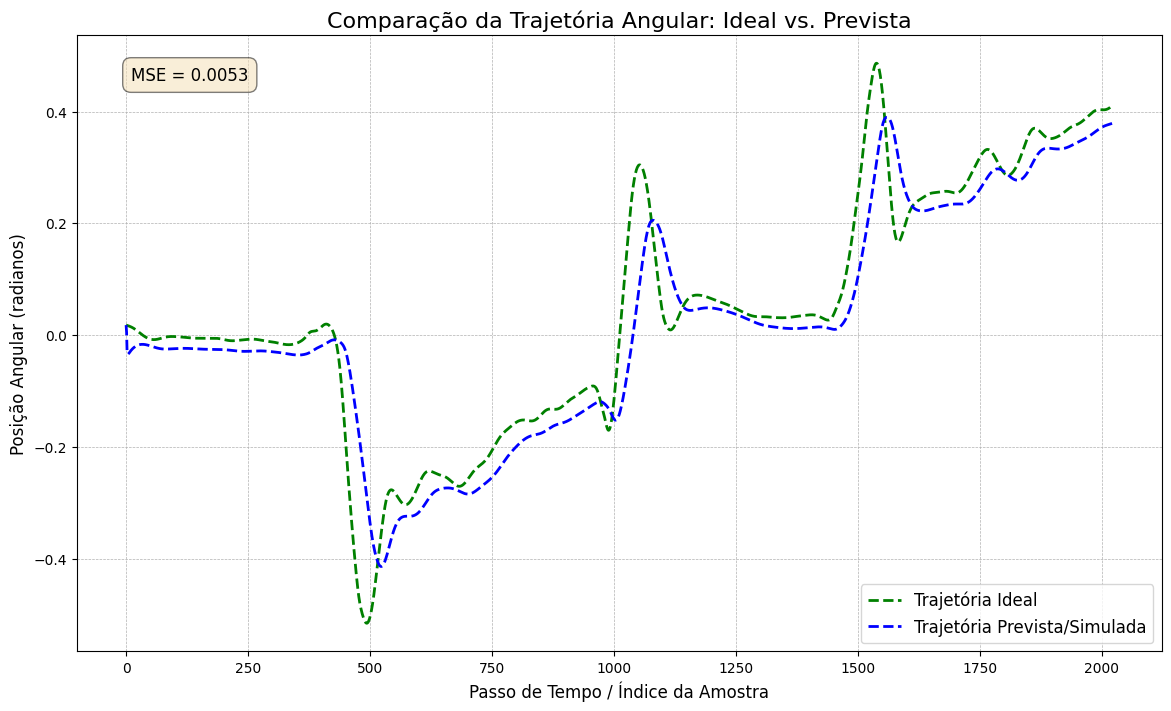

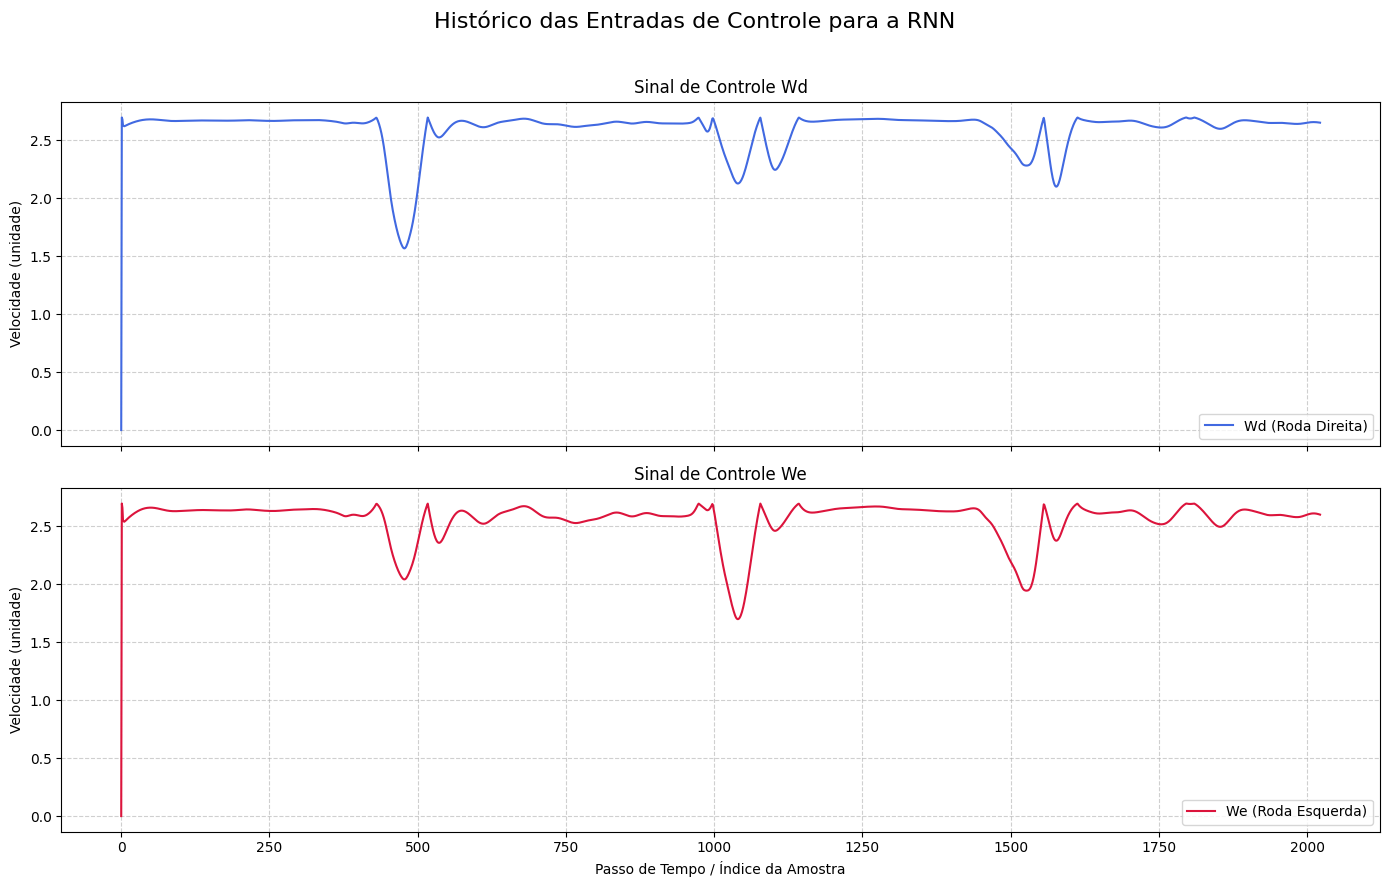

In [12]:
plt.figure(figsize=(14, 8)) # Define um bom tamanho para a figura

# 2. Plote a trajetória ideal
#    'g--' significa: 'g' = green (verde), '--' = linha tracejada
plt.plot(angulos_ideais, 'g--', label='Trajetória Ideal', linewidth=2)

# 3. Plote a trajetória prevista pelo sistema (controlador + RNN)
#    'b-' significa: 'b' = blue (azul), '-' = linha sólida
plt.plot(angulos_preditos, 'b--', label='Trajetória Prevista/Simulada',linewidth=2)

# 4. Adicione títulos e rótulos para clareza
plt.title('Comparação da Trajetória Angular: Ideal vs. Prevista', fontsize=16)
plt.xlabel('Passo de Tempo / Índice da Amostra', fontsize=12)
plt.ylabel('Posição Angular (radianos)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 5. (Opcional) Adicione um texto com o erro (MSE) no gráfico
mse = np.mean((angulos_ideais - angulos_preditos)**2)
plt.text(0.05, 0.95, f'MSE = {mse:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# 6. Exiba o gráfico
plt.show()

fig, axs = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Histórico das Entradas de Controle para a RNN', fontsize=16)

# 2. Plote Wd_controle no primeiro subplot (axs[0])
axs[0].plot(hist_wd, color='royalblue', label='Wd (Roda Direita)')
axs[0].set_title('Sinal de Controle Wd')
axs[0].set_ylabel('Velocidade (unidade)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

# 3. Plote We_controle no segundo subplot (axs[1])
axs[1].plot(hist_we, color='crimson', label='We (Roda Esquerda)')
axs[1].set_title('Sinal de Controle We')
axs[1].set_ylabel('Velocidade (unidade)')
axs[1].set_xlabel('Passo de Tempo / Índice da Amostra')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

# 4. Ajusta o layout para evitar sobreposição e exibe o gráfico
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta para o supertítulo
plt.show()

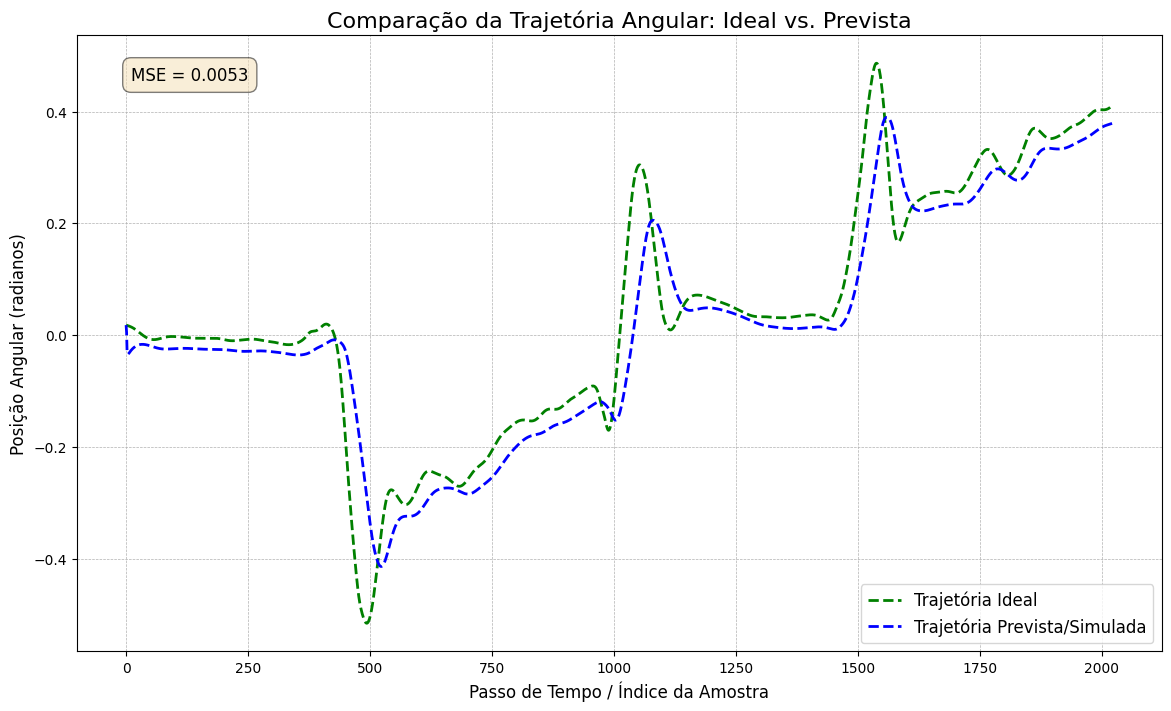

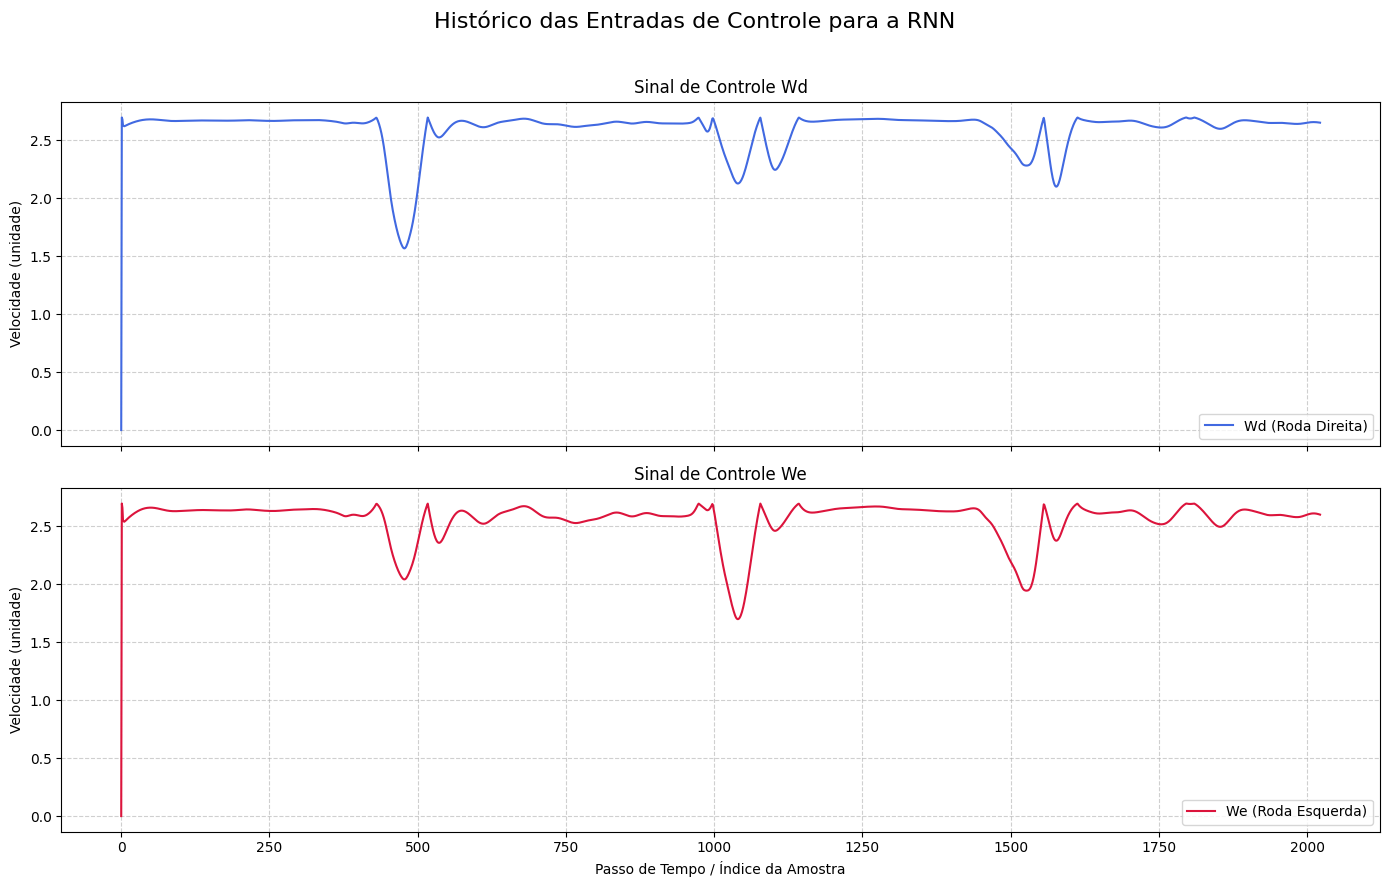

In [7]:
plt.figure(figsize=(14, 8)) # Define um bom tamanho para a figura

# 2. Plote a trajetória ideal
#    'g--' significa: 'g' = green (verde), '--' = linha tracejada
plt.plot(angulos_ideais, 'g--', label='Trajetória Ideal', linewidth=2)

# 3. Plote a trajetória prevista pelo sistema (controlador + RNN)
#    'b-' significa: 'b' = blue (azul), '-' = linha sólida
plt.plot(angulos_preditos, 'b--', label='Trajetória Prevista/Simulada',linewidth=2)

# 4. Adicione títulos e rótulos para clareza
plt.title('Comparação da Trajetória Angular: Ideal vs. Prevista', fontsize=16)
plt.xlabel('Passo de Tempo / Índice da Amostra', fontsize=12)
plt.ylabel('Posição Angular (radianos)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 5. (Opcional) Adicione um texto com o erro (MSE) no gráfico
mse = np.mean((angulos_ideais - angulos_preditos)**2)
plt.text(0.05, 0.95, f'MSE = {mse:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# 6. Exiba o gráfico
plt.show()

fig, axs = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Histórico das Entradas de Controle para a RNN', fontsize=16)

# 2. Plote Wd_controle no primeiro subplot (axs[0])
axs[0].plot(hist_wd, color='royalblue', label='Wd (Roda Direita)')
axs[0].set_title('Sinal de Controle Wd')
axs[0].set_ylabel('Velocidade (unidade)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

# 3. Plote We_controle no segundo subplot (axs[1])
axs[1].plot(hist_we, color='crimson', label='We (Roda Esquerda)')
axs[1].set_title('Sinal de Controle We')
axs[1].set_ylabel('Velocidade (unidade)')
axs[1].set_xlabel('Passo de Tempo / Índice da Amostra')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

# 4. Ajusta o layout para evitar sobreposição e exibe o gráfico
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta para o supertítulo
plt.show()

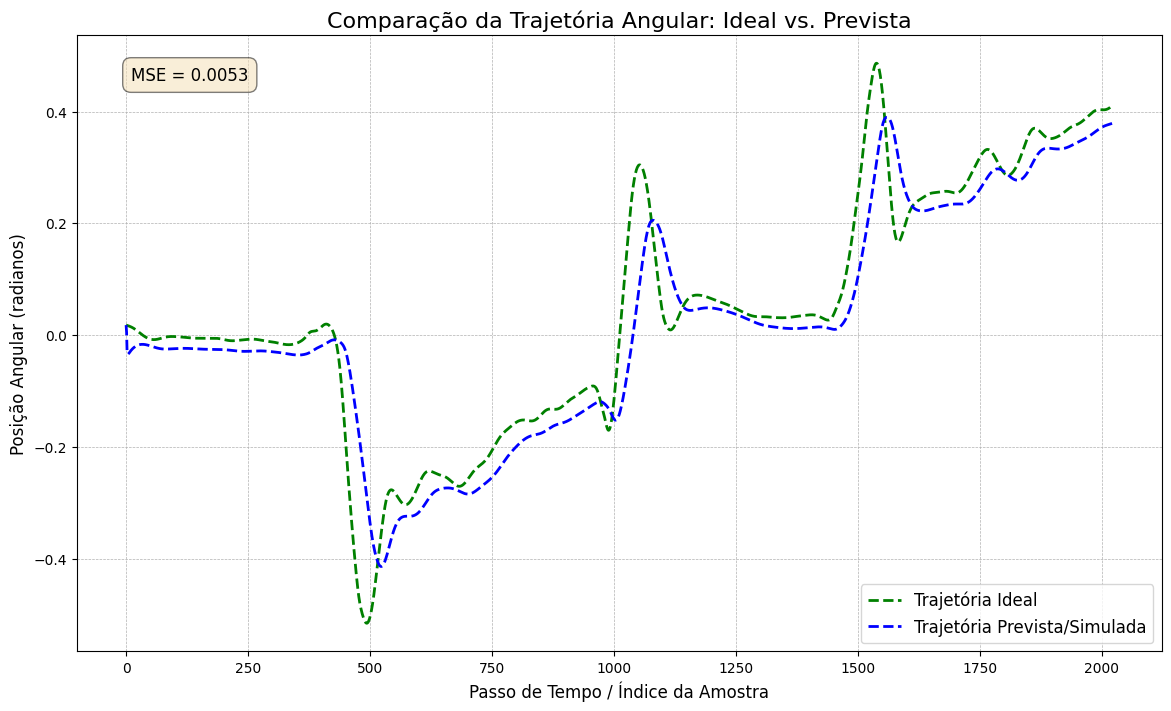

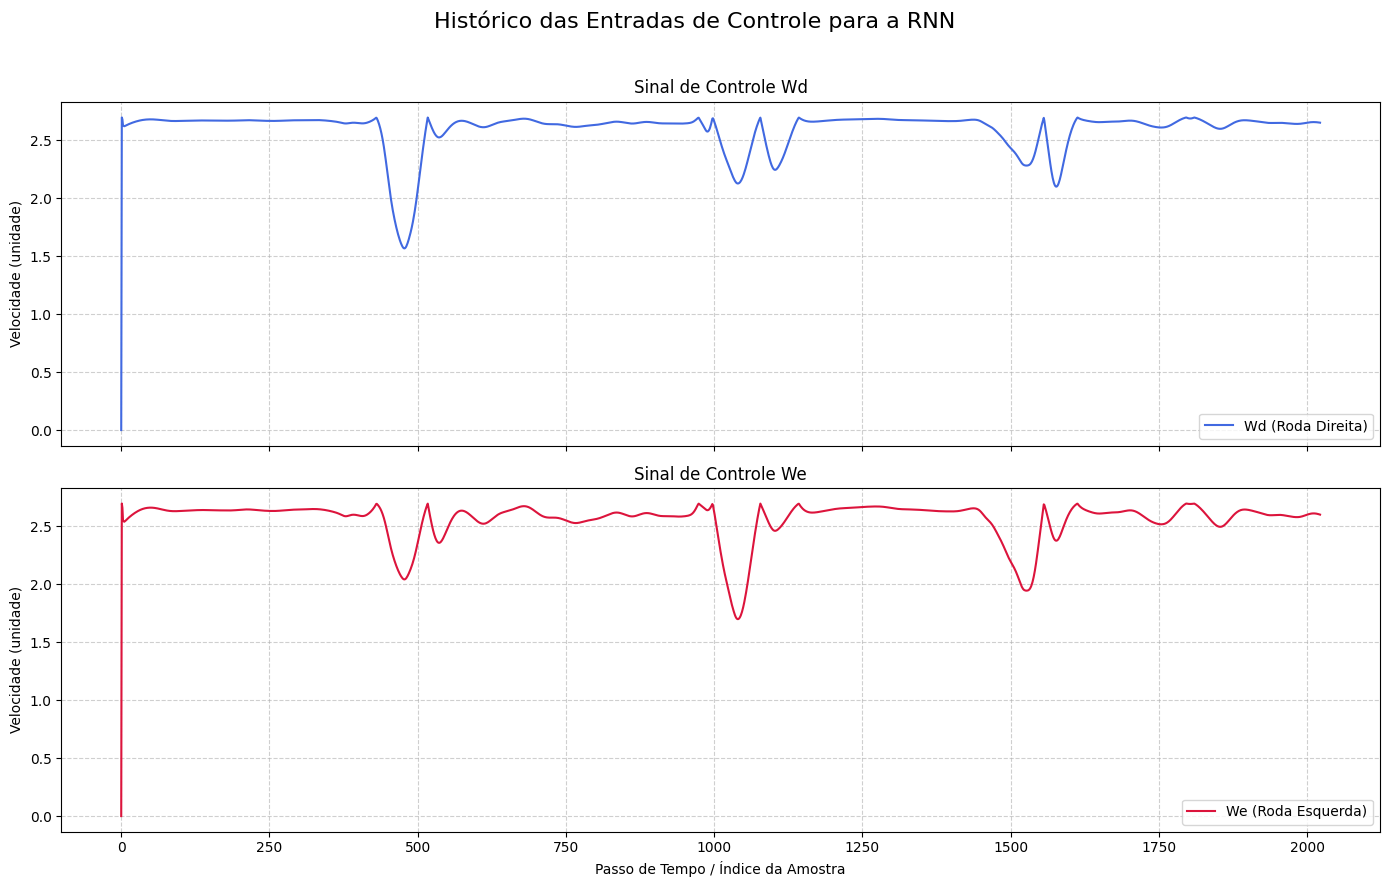

In [8]:
plt.figure(figsize=(14, 8)) # Define um bom tamanho para a figura

# 2. Plote a trajetória ideal
#    'g--' significa: 'g' = green (verde), '--' = linha tracejada
plt.plot(angulos_ideais, 'g--', label='Trajetória Ideal', linewidth=2)

# 3. Plote a trajetória prevista pelo sistema (controlador + RNN)
#    'b-' significa: 'b' = blue (azul), '-' = linha sólida
plt.plot(angulos_preditos, 'b--', label='Trajetória Prevista/Simulada',linewidth=2)

# 4. Adicione títulos e rótulos para clareza
plt.title('Comparação da Trajetória Angular: Ideal vs. Prevista', fontsize=16)
plt.xlabel('Passo de Tempo / Índice da Amostra', fontsize=12)
plt.ylabel('Posição Angular (radianos)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 5. (Opcional) Adicione um texto com o erro (MSE) no gráfico
mse = np.mean((angulos_ideais - angulos_preditos)**2)
plt.text(0.05, 0.95, f'MSE = {mse:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# 6. Exiba o gráfico
plt.show()

fig, axs = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Histórico das Entradas de Controle para a RNN', fontsize=16)

# 2. Plote Wd_controle no primeiro subplot (axs[0])
axs[0].plot(hist_wd, color='royalblue', label='Wd (Roda Direita)')
axs[0].set_title('Sinal de Controle Wd')
axs[0].set_ylabel('Velocidade (unidade)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

# 3. Plote We_controle no segundo subplot (axs[1])
axs[1].plot(hist_we, color='crimson', label='We (Roda Esquerda)')
axs[1].set_title('Sinal de Controle We')
axs[1].set_ylabel('Velocidade (unidade)')
axs[1].set_xlabel('Passo de Tempo / Índice da Amostra')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

# 4. Ajusta o layout para evitar sobreposição e exibe o gráfico
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta para o supertítulo
plt.show()

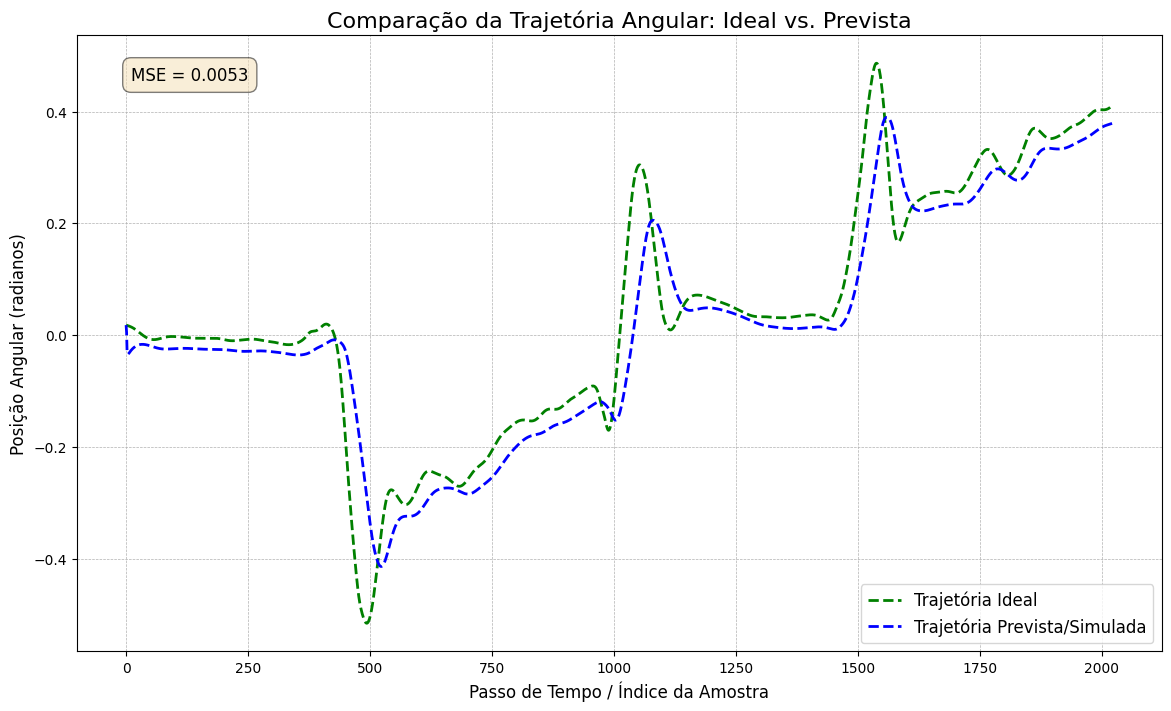

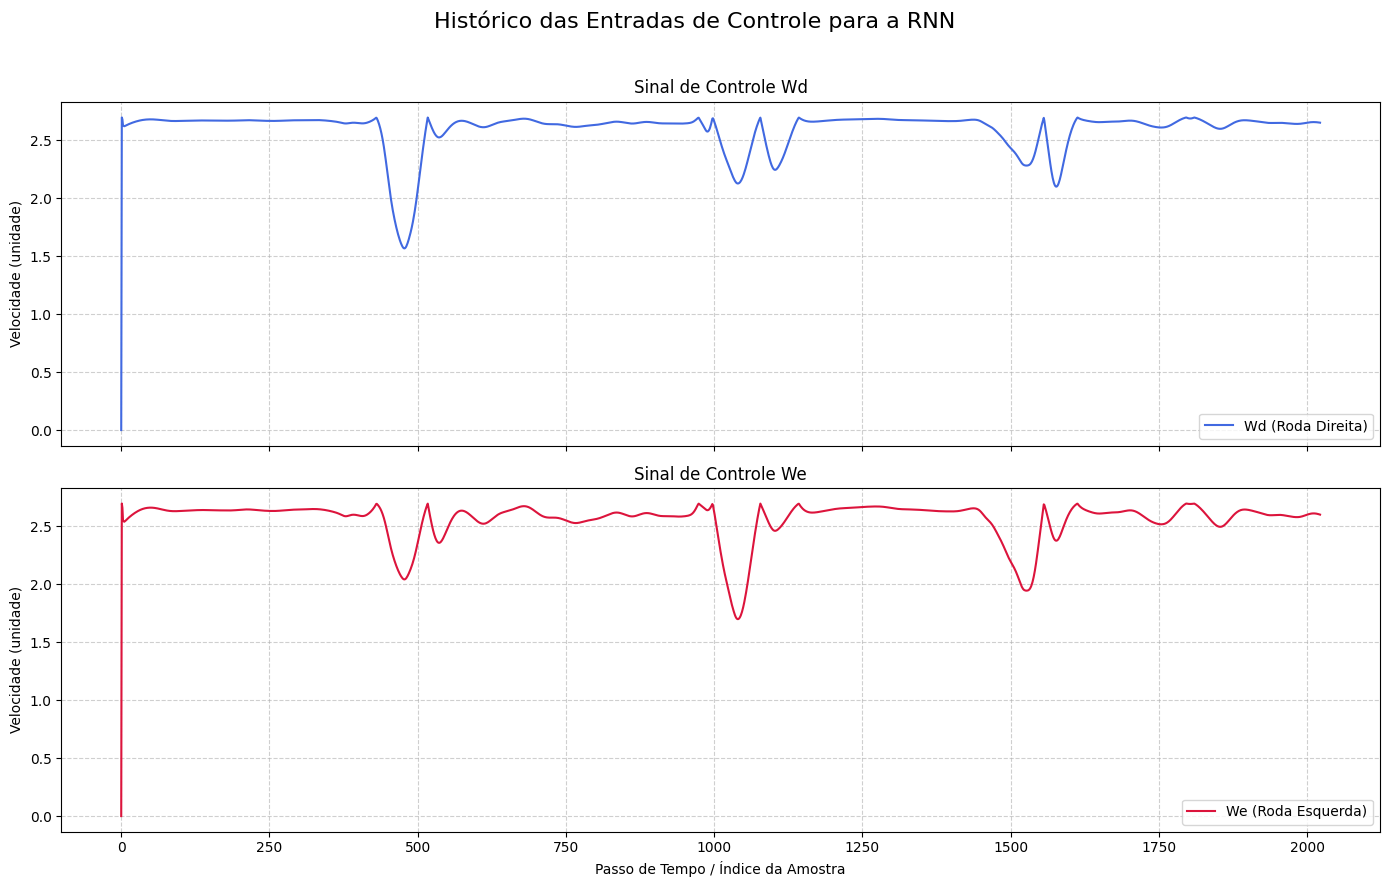

In [9]:
plt.figure(figsize=(14, 8)) # Define um bom tamanho para a figura

# 2. Plote a trajetória ideal
#    'g--' significa: 'g' = green (verde), '--' = linha tracejada
plt.plot(angulos_ideais, 'g--', label='Trajetória Ideal', linewidth=2)

# 3. Plote a trajetória prevista pelo sistema (controlador + RNN)
#    'b-' significa: 'b' = blue (azul), '-' = linha sólida
plt.plot(angulos_preditos, 'b--', label='Trajetória Prevista/Simulada',linewidth=2)

# 4. Adicione títulos e rótulos para clareza
plt.title('Comparação da Trajetória Angular: Ideal vs. Prevista', fontsize=16)
plt.xlabel('Passo de Tempo / Índice da Amostra', fontsize=12)
plt.ylabel('Posição Angular (radianos)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 5. (Opcional) Adicione um texto com o erro (MSE) no gráfico
mse = np.mean((angulos_ideais - angulos_preditos)**2)
plt.text(0.05, 0.95, f'MSE = {mse:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# 6. Exiba o gráfico
plt.show()

fig, axs = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Histórico das Entradas de Controle para a RNN', fontsize=16)

# 2. Plote Wd_controle no primeiro subplot (axs[0])
axs[0].plot(hist_wd, color='royalblue', label='Wd (Roda Direita)')
axs[0].set_title('Sinal de Controle Wd')
axs[0].set_ylabel('Velocidade (unidade)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

# 3. Plote We_controle no segundo subplot (axs[1])
axs[1].plot(hist_we, color='crimson', label='We (Roda Esquerda)')
axs[1].set_title('Sinal de Controle We')
axs[1].set_ylabel('Velocidade (unidade)')
axs[1].set_xlabel('Passo de Tempo / Índice da Amostra')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

# 4. Ajusta o layout para evitar sobreposição e exibe o gráfico
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta para o supertítulo
plt.show()

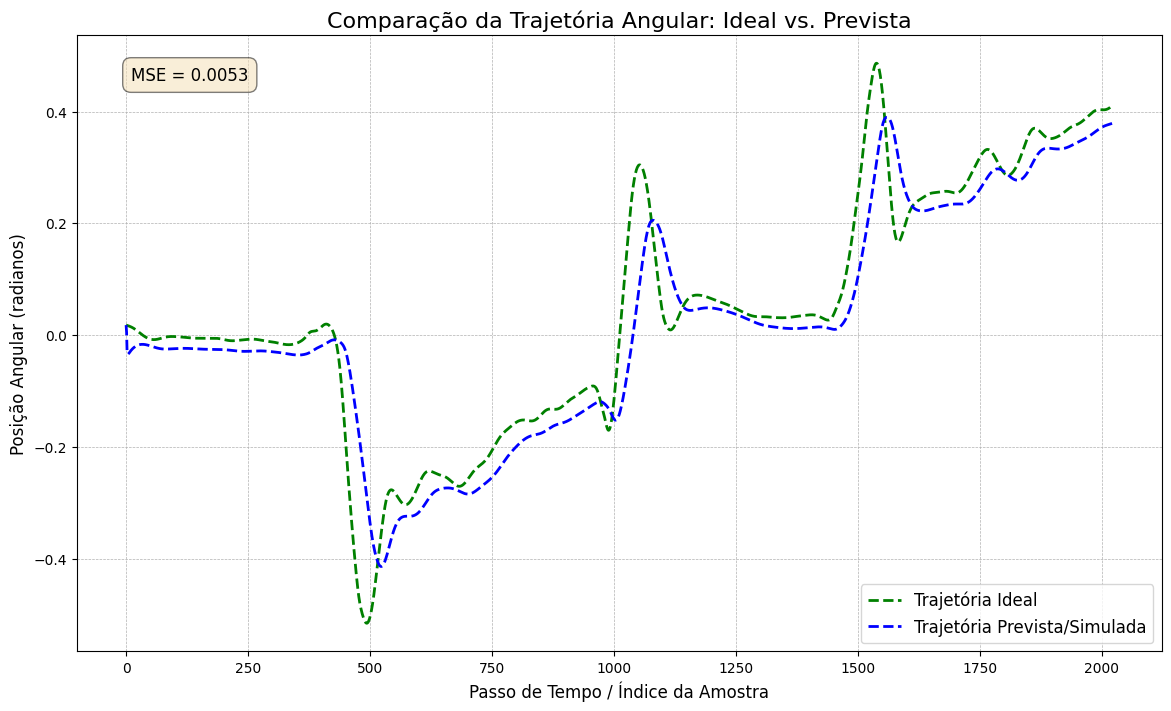

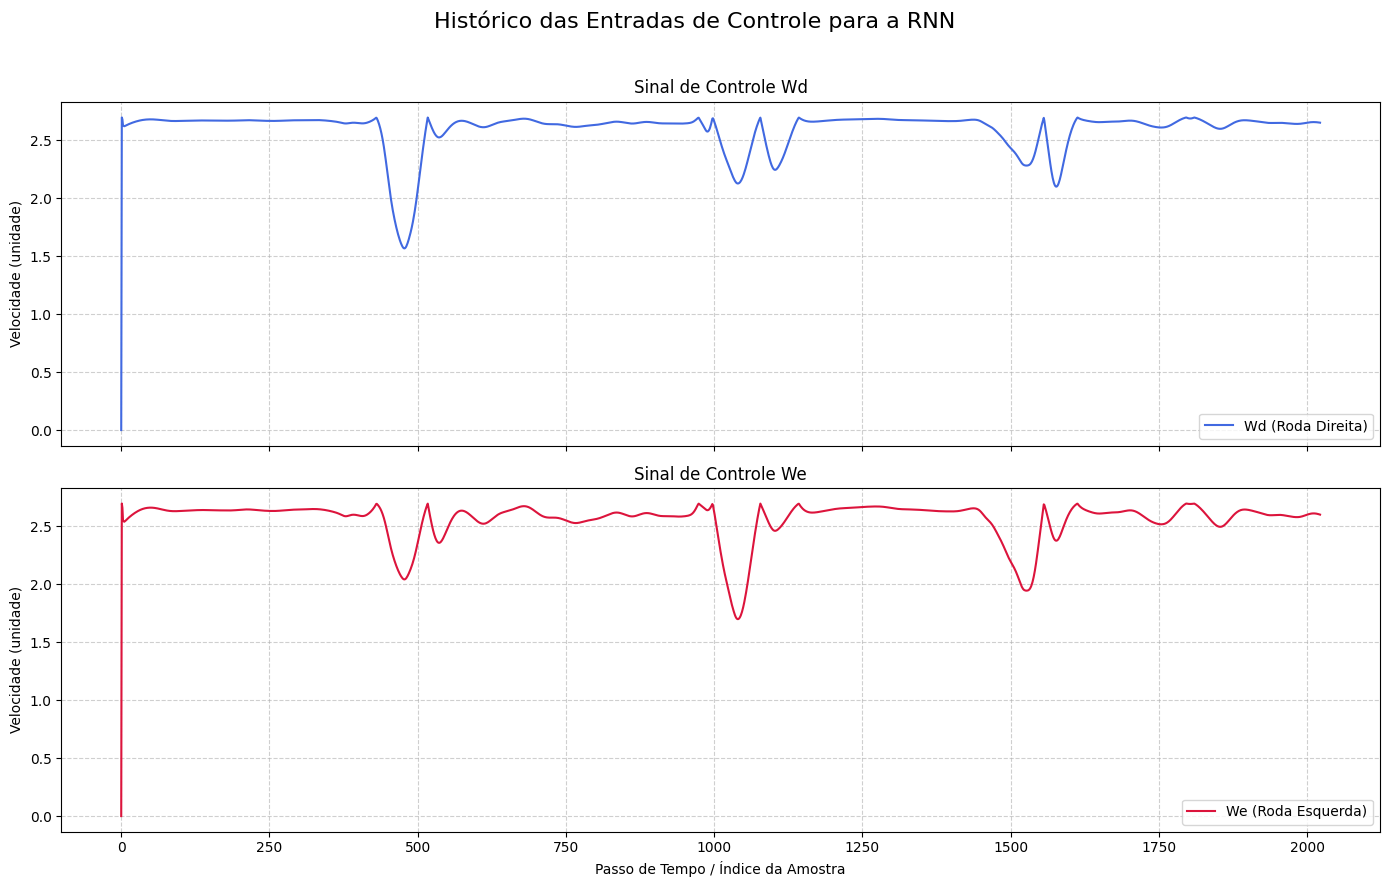

In [10]:
plt.figure(figsize=(14, 8)) # Define um bom tamanho para a figura

# 2. Plote a trajetória ideal
#    'g--' significa: 'g' = green (verde), '--' = linha tracejada
plt.plot(angulos_ideais, 'g--', label='Trajetória Ideal', linewidth=2)

# 3. Plote a trajetória prevista pelo sistema (controlador + RNN)
#    'b-' significa: 'b' = blue (azul), '-' = linha sólida
plt.plot(angulos_preditos, 'b--', label='Trajetória Prevista/Simulada',linewidth=2)

# 4. Adicione títulos e rótulos para clareza
plt.title('Comparação da Trajetória Angular: Ideal vs. Prevista', fontsize=16)
plt.xlabel('Passo de Tempo / Índice da Amostra', fontsize=12)
plt.ylabel('Posição Angular (radianos)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 5. (Opcional) Adicione um texto com o erro (MSE) no gráfico
mse = np.mean((angulos_ideais - angulos_preditos)**2)
plt.text(0.05, 0.95, f'MSE = {mse:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# 6. Exiba o gráfico
plt.show()

fig, axs = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Histórico das Entradas de Controle para a RNN', fontsize=16)

# 2. Plote Wd_controle no primeiro subplot (axs[0])
axs[0].plot(hist_wd, color='royalblue', label='Wd (Roda Direita)')
axs[0].set_title('Sinal de Controle Wd')
axs[0].set_ylabel('Velocidade (unidade)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

# 3. Plote We_controle no segundo subplot (axs[1])
axs[1].plot(hist_we, color='crimson', label='We (Roda Esquerda)')
axs[1].set_title('Sinal de Controle We')
axs[1].set_ylabel('Velocidade (unidade)')
axs[1].set_xlabel('Passo de Tempo / Índice da Amostra')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

# 4. Ajusta o layout para evitar sobreposição e exibe o gráfico
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta para o supertítulo
plt.show()

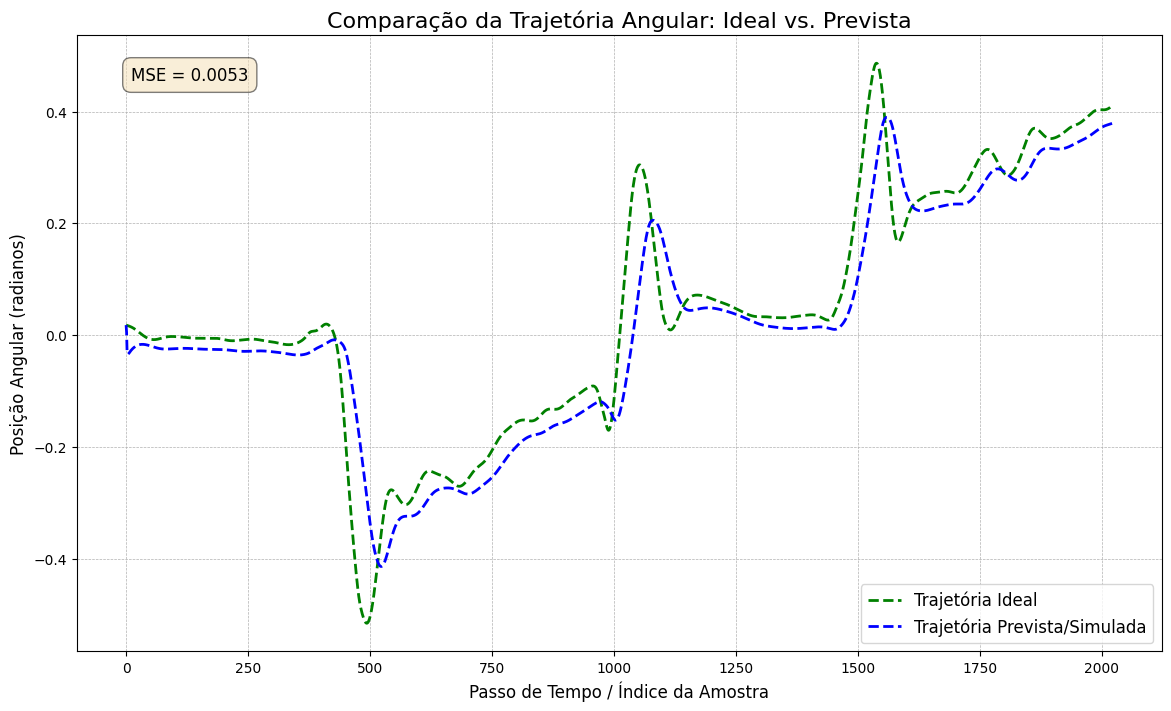

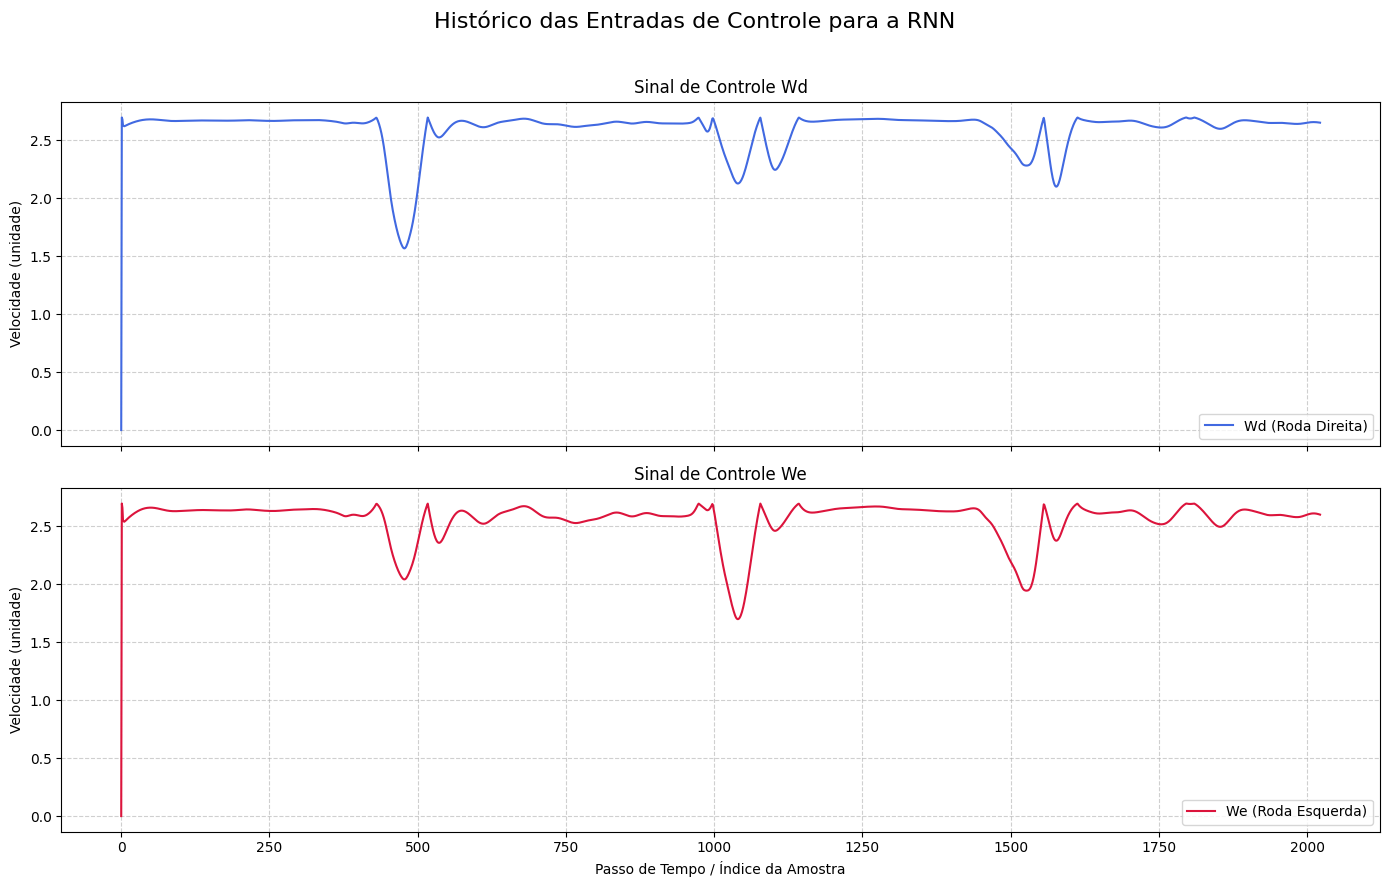

In [11]:
plt.figure(figsize=(14, 8)) # Define um bom tamanho para a figura

# 2. Plote a trajetória ideal
#    'g--' significa: 'g' = green (verde), '--' = linha tracejada
plt.plot(angulos_ideais, 'g--', label='Trajetória Ideal', linewidth=2)

# 3. Plote a trajetória prevista pelo sistema (controlador + RNN)
#    'b-' significa: 'b' = blue (azul), '-' = linha sólida
plt.plot(angulos_preditos, 'b--', label='Trajetória Prevista/Simulada',linewidth=2)

# 4. Adicione títulos e rótulos para clareza
plt.title('Comparação da Trajetória Angular: Ideal vs. Prevista', fontsize=16)
plt.xlabel('Passo de Tempo / Índice da Amostra', fontsize=12)
plt.ylabel('Posição Angular (radianos)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 5. (Opcional) Adicione um texto com o erro (MSE) no gráfico
mse = np.mean((angulos_ideais - angulos_preditos)**2)
plt.text(0.05, 0.95, f'MSE = {mse:.4f}', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# 6. Exiba o gráfico
plt.show()

fig, axs = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Histórico das Entradas de Controle para a RNN', fontsize=16)

# 2. Plote Wd_controle no primeiro subplot (axs[0])
axs[0].plot(hist_wd, color='royalblue', label='Wd (Roda Direita)')
axs[0].set_title('Sinal de Controle Wd')
axs[0].set_ylabel('Velocidade (unidade)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

# 3. Plote We_controle no segundo subplot (axs[1])
axs[1].plot(hist_we, color='crimson', label='We (Roda Esquerda)')
axs[1].set_title('Sinal de Controle We')
axs[1].set_ylabel('Velocidade (unidade)')
axs[1].set_xlabel('Passo de Tempo / Índice da Amostra')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

# 4. Ajusta o layout para evitar sobreposição e exibe o gráfico
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta para o supertítulo
plt.show()